In [ ]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL  = "https://github.com/tackes/Modern-Time-Series-Forecasting-Cohort.git"
    REPO_PATH = "/content/packt-modern-time-series"

    if not os.path.exists(REPO_PATH):
        os.system(f"git clone -q {REPO_URL} {REPO_PATH}")

    os.chdir(f"{REPO_PATH}/instructor_notebooks")

    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)

    os.system("pip install -q statsforecast")

print(f"✓ Setup complete — {os.getcwd()}")

---
# Module 3 — Fast EDA & Data Health
**Type:** [Code With Me — Visualizations]  
**Time:** 15 minutes  
**Job:** Spot seasonality, zeros, and intermittency. Validate the subset. Save the cleaned panel artifact.



---
## 3.1 — Setup
**[Watch Only]**

---

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from config import (
    WORKSHOP_SUBSET_PATH,
    ARTIFACT_DIR,
    MICRO_SUBSET_N,
    WORKSHOP_SUBSET_N,
    RANDOM_SEED,
    SEASON_LENGTH,
    MAX_ZERO_FRACTION,
    HORIZON,
    N_WINDOWS,
    STEP_SIZE,
)
from src.schemas import validate_panel
from src.plotting import (
    plot_sample_series_grid,
    plot_dayofweek_profile,
    plot_histogram,
    plot_cv_windows,
)

print("Setup complete.")

Setup complete.


---
## 3.2 — Load the Panel
**[Watch Only]**

---

In [3]:
panel = pd.read_parquet(WORKSHOP_SUBSET_PATH)
panel = validate_panel(panel, artifact_name="m5_workshop_subset")
panel["ds"] = pd.to_datetime(panel["ds"])

n_series = panel["unique_id"].nunique()
min_date = panel["ds"].min()
max_date = panel["ds"].max()

print(f"Panel: {n_series:,} series, {len(panel):,} rows — {min_date.date()} → {max_date.date()}")

Panel: 1,000 series, 1,941,000 rows — 2011-01-29 → 2016-05-22


**Expected output:**
```
Panel loaded
  Series     : 1,000
  Rows       : ~1,913,000
  Date range : 2011-01-29 → 2016-06-19
  Columns    : ['unique_id', 'ds', 'y']
```

---
## 3.3 — Select the Micro Subset for Live Exploration
**[Watch Only]**

---

In [4]:
# Select MICRO_SUBSET_N series by total sales volume — deterministic, matches subset policy
top_series = (
    panel.groupby("unique_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .head(MICRO_SUBSET_N)
    .index
)

micro = panel[panel["unique_id"].isin(top_series)].copy()

print(f"Micro subset: {micro['unique_id'].nunique()} series, {len(micro):,} rows")

Micro subset: 50 series, 97,050 rows


---
## 3.4 — Plot Sample Series
**[Watch Only]**

---

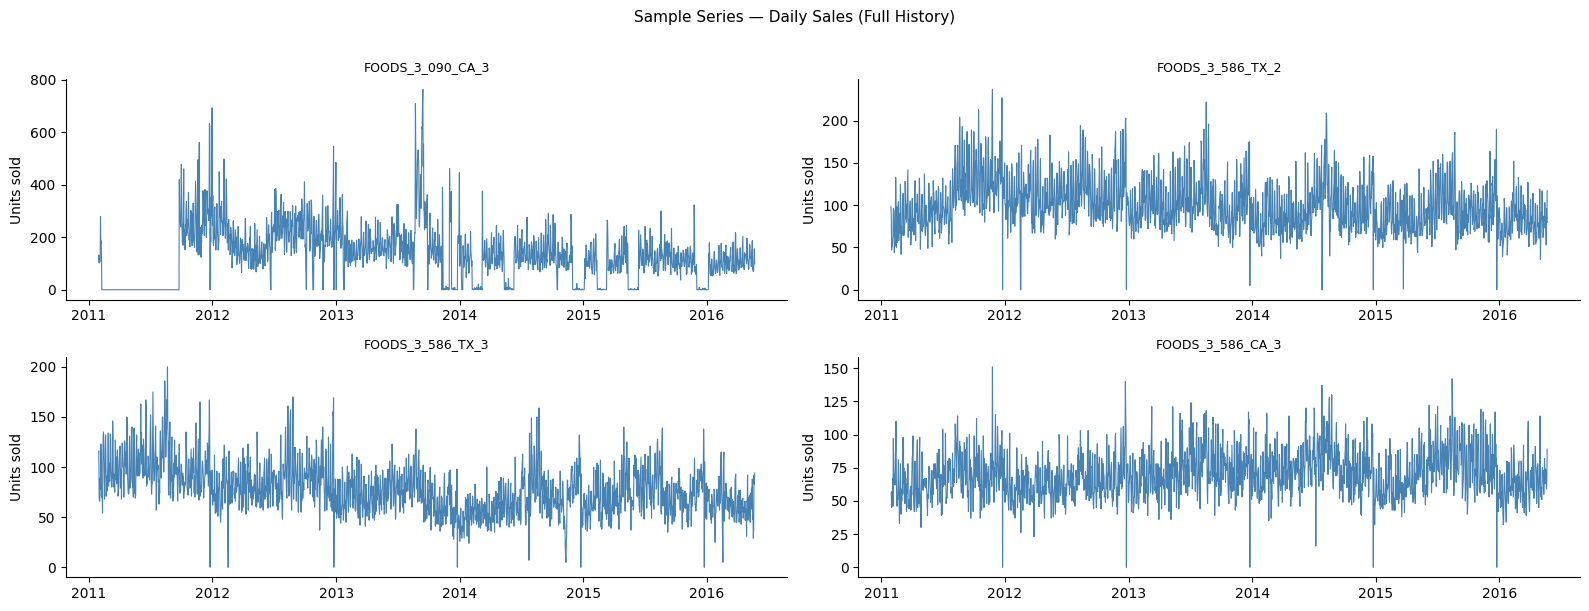

(<Figure size 1600x600 with 4 Axes>,
 array([<Axes: title={'center': 'FOODS_3_090_CA_3'}, ylabel='Units sold'>,
        <Axes: title={'center': 'FOODS_3_586_TX_2'}, ylabel='Units sold'>,
        <Axes: title={'center': 'FOODS_3_586_TX_3'}, ylabel='Units sold'>,
        <Axes: title={'center': 'FOODS_3_586_CA_3'}, ylabel='Units sold'>],
       dtype=object))

In [5]:
sample_ids = list(top_series[:4])

plot_sample_series_grid(
    micro,
    unique_ids=sample_ids,
    title="Sample Series — Daily Sales (Full History)",
)

**Expected output:** Four time series plots. You should see weekly oscillation in all four, varying scale across series, and in some cases a visible upward trend or seasonal level shift around holidays.

---
## 3.5 — Seasonality Check: Average Weekly Profile
**[Watch Only]**

---

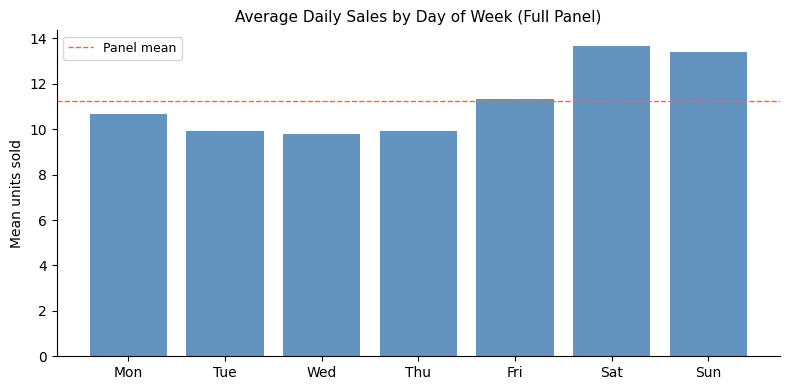

Peak day  : Sat (13.7 units avg)
Trough day: Wed (9.8 units avg)
Peak/trough ratio: 1.40x


In [6]:
fig, ax, dow_profile = plot_dayofweek_profile(
    panel, title="Average Daily Sales by Day of Week (Full Panel)"
)

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(f"Peak day  : {day_labels[dow_profile.idxmax()]} ({dow_profile.max():.1f} units avg)")
print(f"Trough day: {day_labels[dow_profile.idxmin()]} ({dow_profile.min():.1f} units avg)")
print(f"Peak/trough ratio: {dow_profile.max() / dow_profile.min():.2f}x")

**Expected output:** A bar chart showing a clear weekly pattern with a peak/trough ratio > 1.5x.

---
## 3.6 — Intermittency Check
**[Code With Me — 1 line]**

Fill in the lambda to compute the fraction of zero-demand days per series.

---

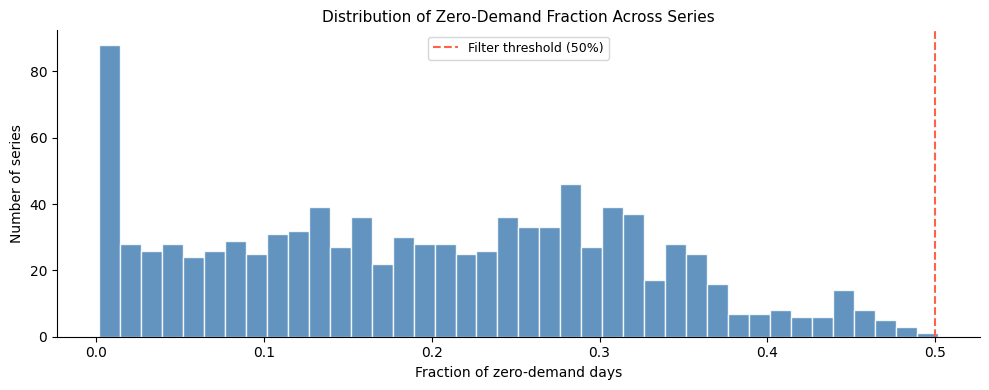

Series with > 30% zero-demand days: 231 of 1,000
Max zero fraction in subset       : 50.18%
Median zero fraction              : 19.27%


In [7]:
# Compute fraction of zero-demand days per series
zero_frac = (
    panel.groupby("unique_id")["y"]
    .apply(lambda s: (s == 0).mean())  # __FILL_IN__: lambda s: fraction of zeros per series
)

plot_histogram(
    zero_frac.values,
    title="Distribution of Zero-Demand Fraction Across Series",
    xlabel="Fraction of zero-demand days",
    threshold=MAX_ZERO_FRACTION,
    threshold_label=f"Filter threshold ({int(MAX_ZERO_FRACTION*100)}%)",
)

n_high_zero = (zero_frac > 0.30).sum()
print(f"Series with > 30% zero-demand days: {n_high_zero} of {len(zero_frac):,}")
print(f"Max zero fraction in subset       : {zero_frac.max():.2%}")
print(f"Median zero fraction              : {zero_frac.median():.2%}")

**Expected output:** Histogram concentrated below 30%. The dashed red line at 50% shows the filter threshold — no series in the workshop subset should exceed it.


---
## 3.7 — History Depth Check
**[Watch Only]**

---

In [8]:
# Verify every series has sufficient history before the first CV cutoff
end_date     = panel["ds"].max()
first_cutoff = end_date - pd.Timedelta(days=(N_WINDOWS * STEP_SIZE))
min_start    = first_cutoff - pd.Timedelta(days=365)

series_starts = panel.groupby("unique_id")["ds"].min()
insufficient  = series_starts[series_starts > min_start]

print(f"End date         : {end_date.date()}")
print(f"First CV cutoff  : {first_cutoff.date()}")
print(f"Min start needed : {min_start.date()}")
print()

if len(insufficient) > 0:
    print(f"  ✗ WARNING — {len(insufficient)} series have insufficient history:")
    print(insufficient.head(5).to_string())
else:
    print(f"  ✓ All {n_series:,} series have ≥ 365 days of history before the first cutoff.")

End date         : 2016-05-22
First CV cutoff  : 2016-02-28
Min start needed : 2015-02-28

  ✓ All 1,000 series have ≥ 365 days of history before the first cutoff.


**Expected output:**
```
End date         : 2016-05-22
First CV cutoff  : 2016-02-28
Min start needed : 2015-02-28

✓ All 1,000 series have >365 days of history before the first cutoff.
```

---
## 3.8 — Gap Check
**[Watch Only]**

---

In [9]:
# ---------------------------------------------------------
# Gap Check: expected daily rows vs observed daily rows
# ---------------------------------------------------------

gap_summary = (
    panel.groupby("unique_id")
    .agg(
        start_date=("ds", "min"),
        end_date=("ds", "max"),
        observed_rows=("ds", "count"),
    )
    .reset_index()
)

gap_summary["expected_rows"] = (
    gap_summary["end_date"] - gap_summary["start_date"]
).dt.days + 1

gap_summary["missing_rows"] = (
    gap_summary["expected_rows"] - gap_summary["observed_rows"]
)

gap_summary["missing_pct"] = (
    gap_summary["missing_rows"] / gap_summary["expected_rows"]
)

print("Gap summary across series")
print(gap_summary["missing_pct"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(3))

print("\nTop 10 gappiest series")
display(
    gap_summary.sort_values("missing_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

Gap summary across series
count    1000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
90%         0.0
max         0.0
Name: missing_pct, dtype: float64

Top 10 gappiest series


,unique_id,start_date,end_date,observed_rows,expected_rows,missing_rows,missing_pct
0,FOODS_1_004_CA_1,2011-01-29,2016-05-22,1941,1941,0,0.0
1,FOODS_1_004_CA_2,2011-01-29,2016-05-22,1941,1941,0,0.0
2,FOODS_1_004_CA_3,2011-01-29,2016-05-22,1941,1941,0,0.0
3,FOODS_1_004_TX_1,2011-01-29,2016-05-22,1941,1941,0,0.0
4,FOODS_1_004_TX_2,2011-01-29,2016-05-22,1941,1941,0,0.0
5,FOODS_1_004_TX_3,2011-01-29,2016-05-22,1941,1941,0,0.0
6,FOODS_1_004_WI_1,2011-01-29,2016-05-22,1941,1941,0,0.0
7,FOODS_1_004_WI_2,2011-01-29,2016-05-22,1941,1941,0,0.0
8,FOODS_1_004_WI_3,2011-01-29,2016-05-22,1941,1941,0,0.0
9,FOODS_1_012_CA_2,2011-01-29,2016-05-22,1941,1941,0,0.0


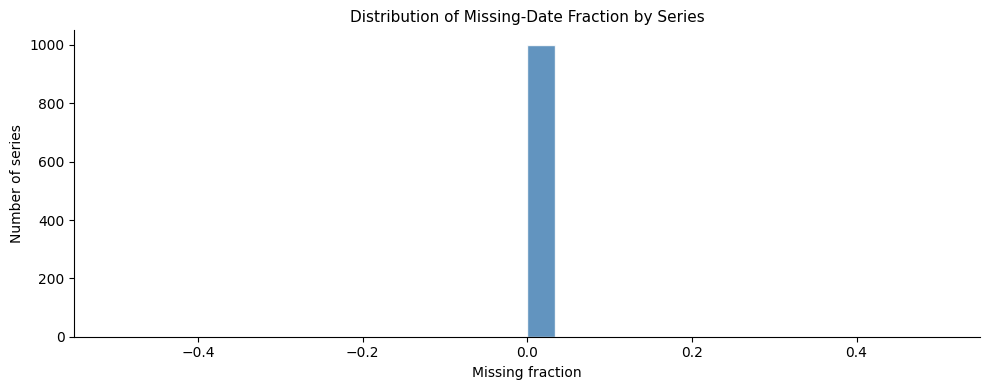

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Missing-Date Fraction by Series'}, xlabel='Missing fraction', ylabel='Number of series'>)

In [10]:
plot_histogram(
    gap_summary["missing_pct"],
    title="Distribution of Missing-Date Fraction by Series",
    xlabel="Missing fraction",
    bins=30,
)

---
### 3.8b — Fill Gaps with `utilsforecast.preprocessing.fill_gaps`
**[Watch Only]**

This dataset has no gaps — which is why we check first before fixing. On your own datasets you will almost certainly find gaps.

**Fill strategy is a domain decision:**

| Strategy | When to use |
|---|---|
| **Zero-fill** | Store was open, nothing sold |
| **Forward-fill** | Sensor/price data — value didn't change, wasn't recorded |
| **Drop the series** | Gap > 30% of history, or gap spans a full season |
| **Interpolate** | Almost never right for demand |



> Key idea: `fill_gaps` creates a complete date grid and returns `NaN` for missing rows. You apply the fill strategy explicitly — there is no default.

---

In [11]:
# 3.8b — Fill gaps (no-op on this dataset — all series are complete)
from utilsforecast.preprocessing import fill_gaps

n_before      = len(panel)
panel_filled  = fill_gaps(panel, freq="D")
n_added       = len(panel_filled) - n_before

print(f"Rows before: {n_before:,}  |  Added: {n_added:,}  |  After: {len(panel_filled):,}")

if n_added > 0:
    panel_filled["y"] = panel_filled["y"].fillna(0)   # zero-fill: store was open, nothing sold
    assert panel_filled[["unique_id", "ds", "y"]].isnull().sum().sum() == 0

gap_check = (
    panel_filled.groupby("unique_id")
    .agg(start=("ds", "min"), end=("ds", "max"), n=("ds", "count"))
    .assign(expected=lambda d: (d["end"] - d["start"]).dt.days + 1)
    .assign(gaps=lambda d: d["expected"] - d["n"])
)
assert gap_check["gaps"].sum() == 0, "Gaps remain after fill — check fill strategy."
print(f"Gap assertion passed: all {panel_filled['unique_id'].nunique():,} series are contiguous.")

panel = panel_filled

Rows before: 1,941,000  |  Added: 0  |  After: 1,941,000
Gap assertion passed: all 1,000 series are contiguous.


---
## 3.9 — CV Cutoff Visualization
**[Watch Only]**

---

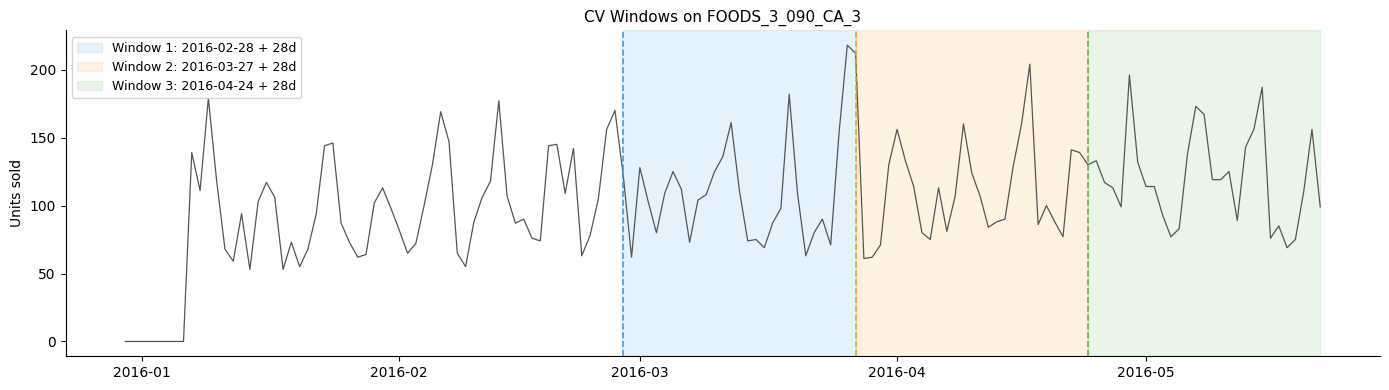

Cross-validation cutoffs:
  Window 1: cutoff=2016-02-28  forecast window: 2016-02-28 → 2016-03-27
  Window 2: cutoff=2016-03-27  forecast window: 2016-03-27 → 2016-04-24
  Window 3: cutoff=2016-04-24  forecast window: 2016-04-24 → 2016-05-22


In [12]:
# Visualize the 3 CV windows on a single representative series
sample_uid = top_series[0]
sample_ts  = panel[panel["unique_id"] == sample_uid].set_index("ds")["y"]

cutoffs = [
    end_date - pd.Timedelta(days=(N_WINDOWS - i) * STEP_SIZE)
    for i in range(N_WINDOWS)
]

plot_cv_windows(
    series=sample_ts,
    cutoffs=cutoffs,
    horizon=HORIZON,
    title=f"CV Windows on {sample_uid}",
)

print("Cross-validation cutoffs:")
for i, c in enumerate(cutoffs):
    print(f"  Window {i+1}: cutoff={c.date()}  forecast window: {c.date()} → {(c + pd.Timedelta(days=HORIZON)).date()}")

**Expected output:** A time series chart with three shaded forecast windows, each 28 days wide, spaced 28 days apart. Dashed vertical lines mark the cutoff dates.


---
## 3.9 — Save the Validated Panel Artifact
**[Watch Only]**

> **Instructor note (30 sec):** Drop the helper column added for EDA, validate schema one final time, save. Quick.

In [13]:
from src.schemas import validate_panel

# Drop EDA helper column before saving
panel_clean = panel.drop(columns=["dow"], errors="ignore")
panel_clean = validate_panel(panel_clean, artifact_name="03_validated_panel")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
artifact_path = ARTIFACT_DIR / "03_validated_panel.parquet"
panel_clean.to_parquet(artifact_path, index=False)

print(f"  ✓ Validated panel saved: {artifact_path.name}")
print(f"    Rows   : {len(panel_clean):,}")
print(f"    Series : {panel_clean['unique_id'].nunique():,}")

  ✓ Validated panel saved: 03_validated_panel.parquet
    Rows   : 1,941,000
    Series : 1,000


**Expected output:**
```
  ✓ Validated panel saved: 03_validated_panel.parquet
    Rows   : ~1,913,000
    Series : 1,000
```